# Analyse Exploratoire — Mutual Funds & ETFs

**Objectif métier** : prédire le rendement annualisé futur d'un fonds entre sa 3e et sa 5e année ($R_{3 \to 5}$), en utilisant uniquement les informations disponibles à l'issue de l'an 3.

**Formule de la target** :
$$R_{3 \to 5} = \left(\frac{(1 + R_5)^5}{(1 + R_3)^3}\right)^{\frac{1}{2}} - 1$$

Cette formule isole la performance *pure* post-an3, en retirant la contribution des 3 premières années via intérêts composés.

In [1]:
import sys
sys.path.insert(0, '../src')

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from config import MUTUAL_FUNDS_CSV
from data import FEATURES, _compute_target

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

## 1. Chargement et calcul de la target

In [2]:
df_raw = pd.read_csv(MUTUAL_FUNDS_CSV, low_memory=False)
print(f'Dimensions brutes : {df_raw.shape}')

df_raw['R_3_to_5'] = _compute_target(df_raw)
df = df_raw.dropna(subset=['R_3_to_5', 'fund_return_3years', 'fund_return_5years'])
df = df[~np.isinf(df['R_3_to_5'])].copy()

print(f'Dimensions apres nettoyage : {df.shape}')
print(f'Fonds supprimes (NaN target): {len(df_raw) - len(df):,}')

Dimensions brutes : (23783, 298)
Dimensions apres nettoyage : (17022, 299)
Fonds supprimes (NaN target): 6,761


## 2. Distribution de la target $R_{3 \to 5}$

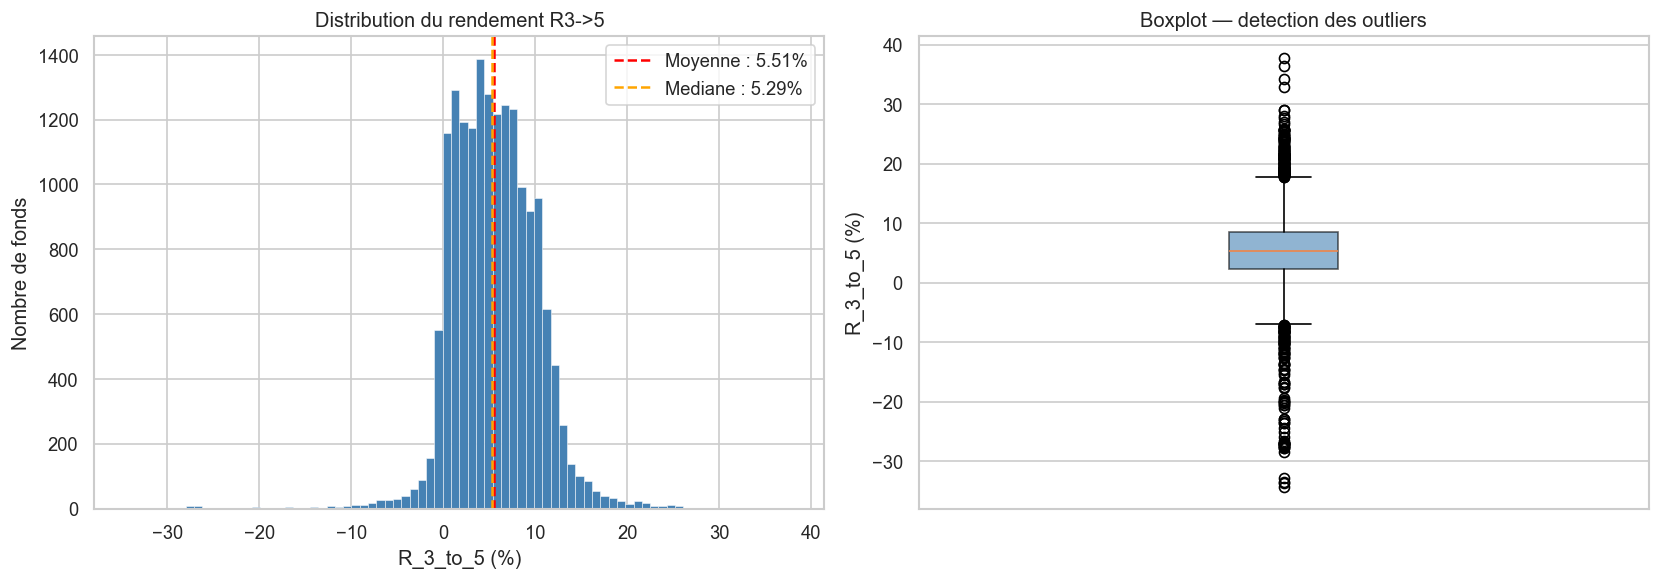

count    17022.000
mean         5.512
std          4.667
min        -34.352
25%          2.273
50%          5.290
75%          8.498
max         37.820


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogramme
axes[0].hist(df['R_3_to_5'], bins=80, color='steelblue', edgecolor='white', linewidth=0.3)
axes[0].axvline(df['R_3_to_5'].mean(), color='red', linestyle='--', label=f"Moyenne : {df['R_3_to_5'].mean():.2f}%")
axes[0].axvline(df['R_3_to_5'].median(), color='orange', linestyle='--', label=f"Mediane : {df['R_3_to_5'].median():.2f}%")
axes[0].set_xlabel('R_3_to_5 (%)')
axes[0].set_ylabel('Nombre de fonds')
axes[0].set_title('Distribution du rendement R3->5')
axes[0].legend()

# Boxplot
axes[1].boxplot(df['R_3_to_5'], vert=True, patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.6))
axes[1].set_ylabel('R_3_to_5 (%)')
axes[1].set_title('Boxplot — detection des outliers')
axes[1].set_xticks([])

plt.tight_layout()
plt.savefig('../plots/01_distribution_target.png', bbox_inches='tight')
plt.show()

print(df['R_3_to_5'].describe().round(3).to_string())

## 3. Valeurs manquantes dans les features

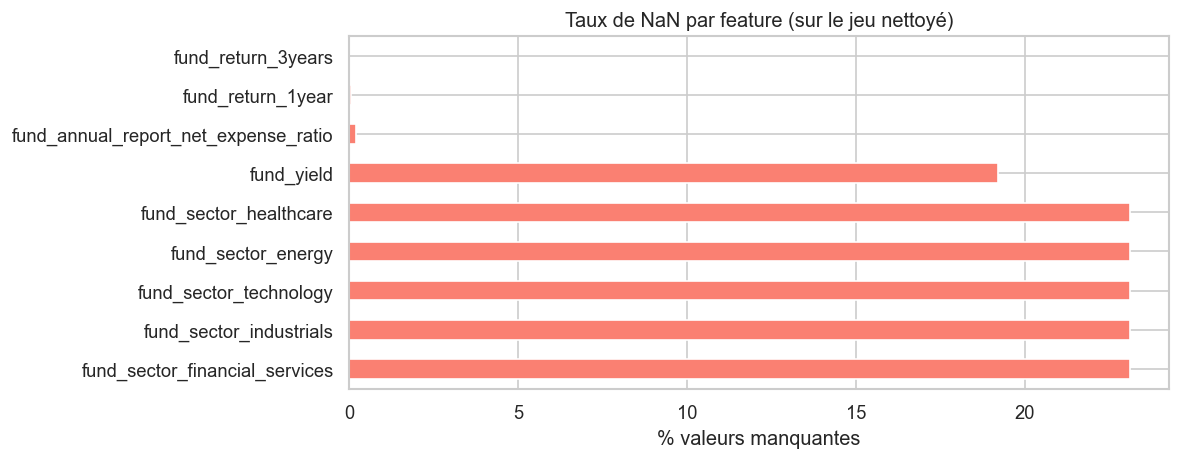

fund_sector_financial_services          23.1
fund_sector_industrials                 23.1
fund_sector_technology                  23.1
fund_sector_energy                      23.1
fund_sector_healthcare                  23.1
fund_yield                              19.2
fund_annual_report_net_expense_ratio     0.2
fund_return_1year                        0.0
fund_return_3years                       0.0


In [4]:
feature_cols = [f for f in FEATURES if f in df.columns]
missing = df[feature_cols].isna().mean().sort_values(ascending=False) * 100

fig, ax = plt.subplots(figsize=(10, 4))
missing.plot(kind='barh', ax=ax, color='salmon')
ax.set_xlabel('% valeurs manquantes')
ax.set_title('Taux de NaN par feature (sur le jeu nettoyé)')
plt.tight_layout()
plt.savefig('../plots/02_valeurs_manquantes.png', bbox_inches='tight')
plt.show()

print(missing.round(1).to_string())

> Les NaN dans les features sectorielles sont gérés automatiquement par le `SimpleImputer(strategy='median')` encapsulé dans chaque pipeline.

## 4. Statistiques descriptives des features

In [5]:
df[feature_cols + ['R_3_to_5']].describe().T.round(4)

,count,mean,std,min,25%,50%,75%,max
fund_return_1year,17016.0,0.2399,0.1813,-0.6379,0.0780,0.2511,0.3654,1.3503
fund_return_3years,17022.0,0.1008,0.0732,-0.5127,0.0546,0.0900,0.1353,0.6482
fund_yield,13753.0,0.0176,0.0261,0.0001,0.0070,0.0137,0.0225,1.2585
fund_sector_technology,13089.0,0.1656,0.1154,0.0000,0.0916,0.1709,0.2242,1.0000
fund_sector_financial_services,13089.0,0.1464,0.1244,0.0000,0.0828,0.1477,0.1825,1.0000
fund_sector_healthcare,13089.0,0.1150,0.1049,0.0000,0.0644,0.1173,0.1423,1.0000
fund_sector_energy,13089.0,0.0686,0.1752,0.0000,0.0029,0.0279,0.0471,1.0000
fund_sector_industrials,13089.0,0.1116,0.0876,0.0000,0.0656,0.1093,0.1462,1.0000
fund_annual_report_net_expense_ratio,16987.0,0.0110,0.0058,0.0001,0.0071,0.0100,0.0140,0.1180
R_3_to_5,17022.0,5.5121,4.6670,-34.3523,2.2731,5.2903,8.4978,37.8199


## 5. Matrice de corrélation

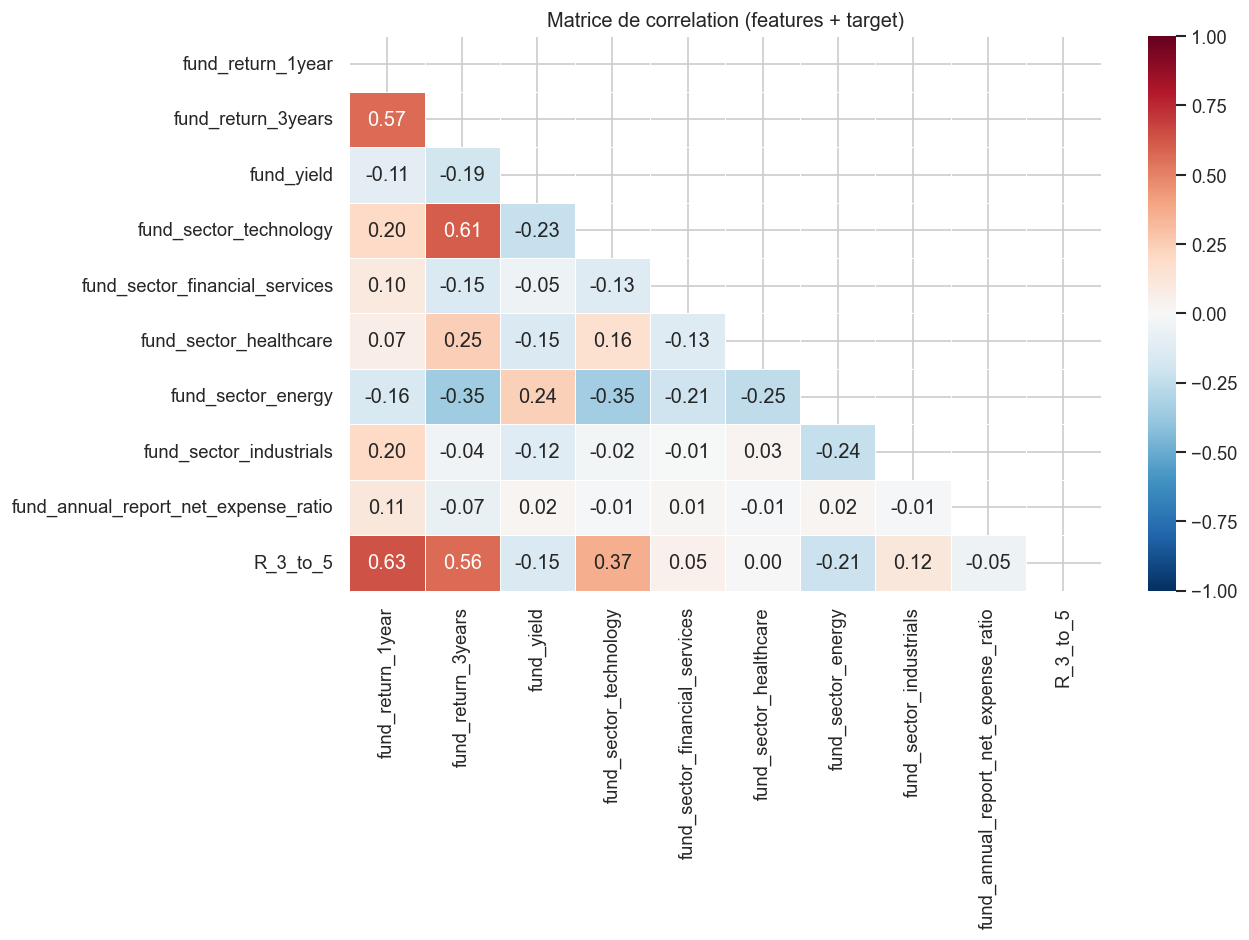

In [6]:
corr_matrix = df[feature_cols + ['R_3_to_5']].corr()

fig, ax = plt.subplots(figsize=(11, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
    center=0, linewidths=0.5, ax=ax, vmin=-1, vmax=1
)
ax.set_title('Matrice de correlation (features + target)')
plt.tight_layout()
plt.savefig('../plots/03_correlation_matrix.png', bbox_inches='tight')
plt.show()

## 6. Corrélation individuelle avec la target

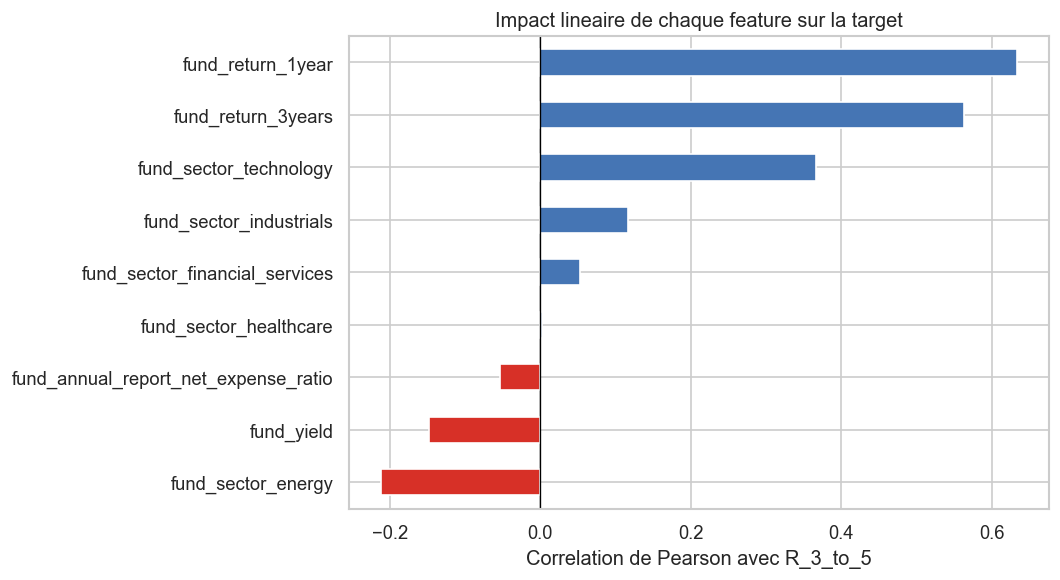

fund_return_1year                       0.634
fund_return_3years                      0.563
fund_sector_technology                  0.367
fund_sector_industrials                 0.116
fund_sector_financial_services          0.053
fund_sector_healthcare                  0.002
fund_annual_report_net_expense_ratio   -0.053
fund_yield                             -0.148
fund_sector_energy                     -0.212


In [7]:
corr_target = corr_matrix['R_3_to_5'].drop('R_3_to_5').sort_values()

colors = ['#d73027' if v < 0 else '#4575b4' for v in corr_target]
fig, ax = plt.subplots(figsize=(9, 5))
corr_target.plot(kind='barh', ax=ax, color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Correlation de Pearson avec R_3_to_5')
ax.set_title('Impact lineaire de chaque feature sur la target')
plt.tight_layout()
plt.savefig('../plots/04_correlation_target.png', bbox_inches='tight')
plt.show()

print(corr_target.round(3).sort_values(ascending=False).to_string())

## 7. Scatter plots : features vs target

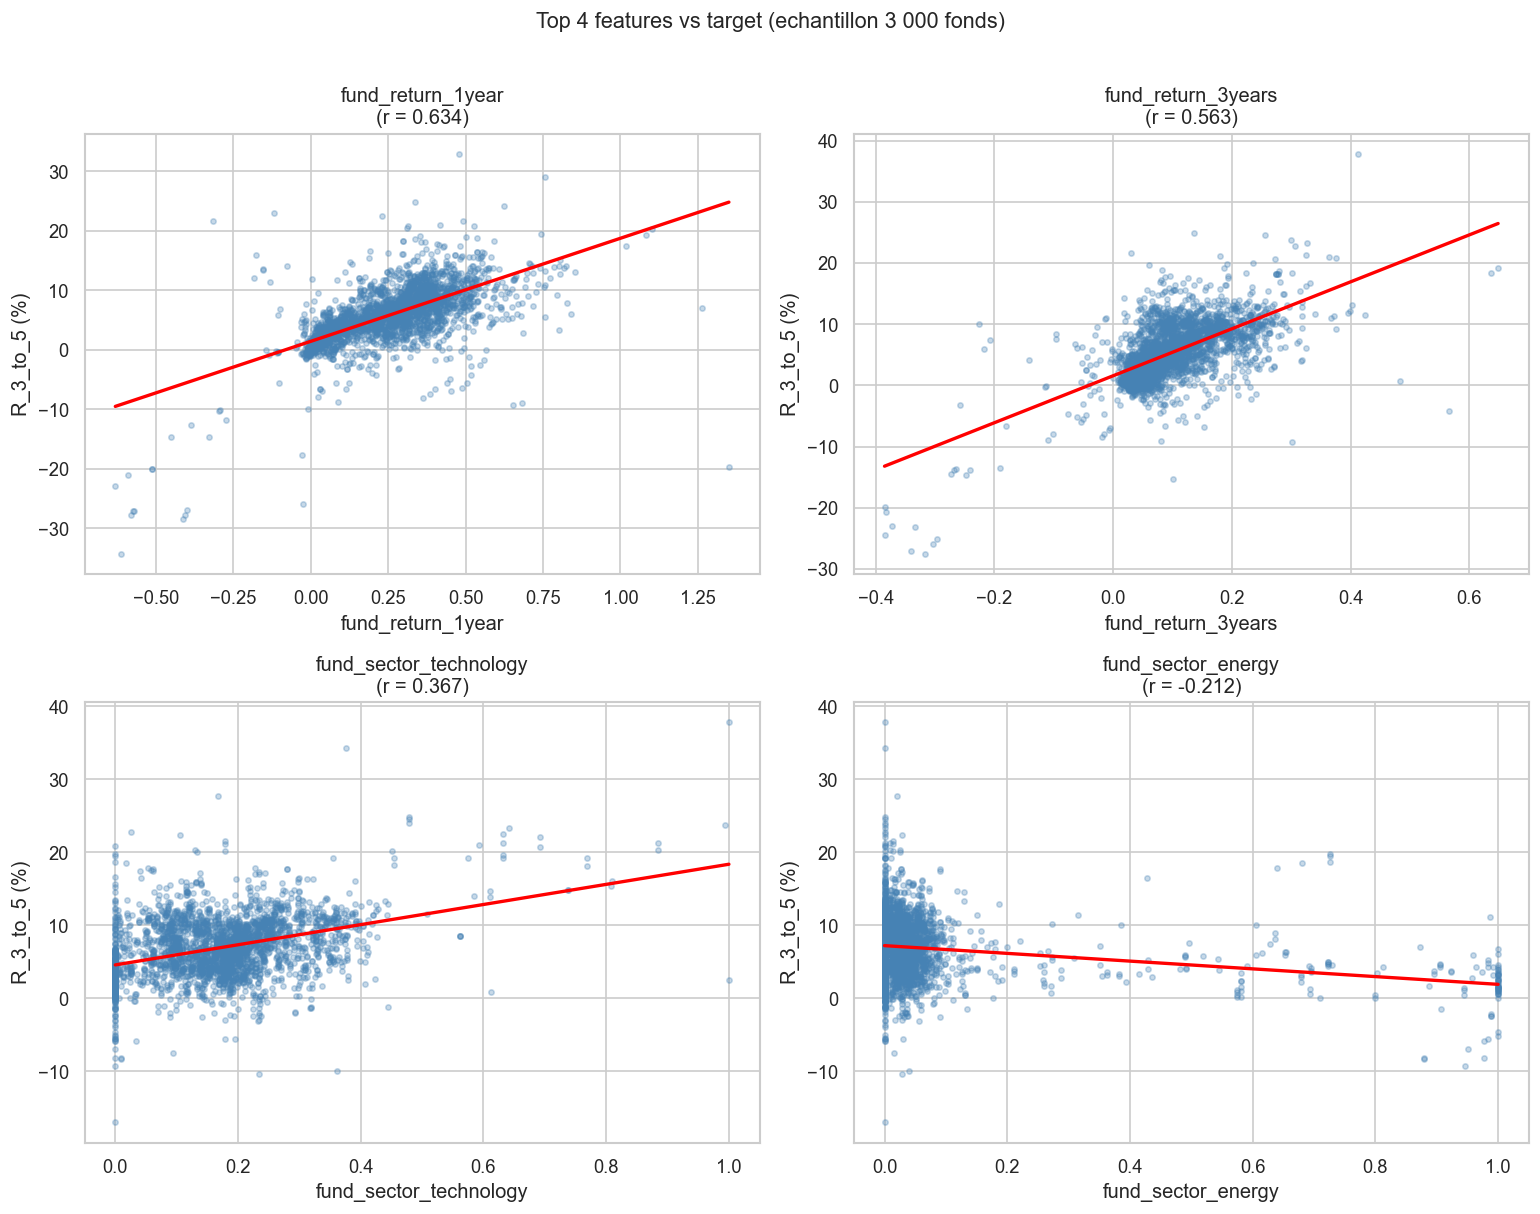

In [8]:
top_features = corr_target.abs().sort_values(ascending=False).head(4).index.tolist()

fig, axes = plt.subplots(2, 2, figsize=(13, 10))
axes = axes.flatten()

for i, feat in enumerate(top_features):
    sample = df[[feat, 'R_3_to_5']].dropna().sample(min(3000, len(df)), random_state=42)
    axes[i].scatter(sample[feat], sample['R_3_to_5'], alpha=0.3, s=10, color='steelblue')
    # Droite de régression
    z = np.polyfit(sample[feat], sample['R_3_to_5'], 1)
    p = np.poly1d(z)
    x_range = np.linspace(sample[feat].min(), sample[feat].max(), 100)
    axes[i].plot(x_range, p(x_range), color='red', linewidth=2)
    axes[i].set_xlabel(feat)
    axes[i].set_ylabel('R_3_to_5 (%)')
    axes[i].set_title(f'{feat}\n(r = {corr_target[feat]:.3f})')

plt.suptitle('Top 4 features vs target (echantillon 3 000 fonds)', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('../plots/05_scatter_features.png', bbox_inches='tight')
plt.show()

## 8. Répartition positif / négatif (Win Rate baseline)

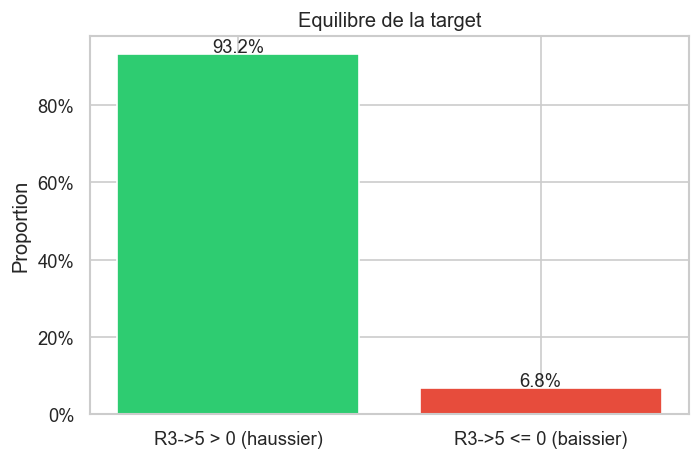

Fonds haussiers : 15,869 (93.2%)
Fonds baissiers : 1,153 (6.8%)
Un modele naif "toujours positif" obtiendrait un Win Rate de 93.2%


In [9]:
positive = (df['R_3_to_5'] > 0).sum()
negative = (df['R_3_to_5'] <= 0).sum()
total = len(df)

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(['R3->5 > 0 (haussier)', 'R3->5 <= 0 (baissier)'],
       [positive / total, negative / total],
       color=['#2ecc71', '#e74c3c'])
ax.set_ylabel('Proportion')
ax.set_title('Equilibre de la target')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
for rect, val in zip(ax.patches, [positive/total, negative/total]):
    ax.text(rect.get_x() + rect.get_width()/2, rect.get_height() + 0.005,
            f'{val:.1%}', ha='center', fontsize=11)
plt.tight_layout()
plt.savefig('../plots/06_equilibre_target.png', bbox_inches='tight')
plt.show()

print(f'Fonds haussiers : {positive:,} ({positive/total:.1%})')
print(f'Fonds baissiers : {negative:,} ({negative/total:.1%})')
print(f'Un modele naif "toujours positif" obtiendrait un Win Rate de {positive/total:.1%}')